# E-commerce Customer Churn Prediction

## End-to-End ML Pipeline: Data Cleaning, EDA, Feature Engineering & Model Comparison

## 1. Introduction & Problem Statement

### Business Context
Customer churn is one of the most critical challenges for e-commerce businesses. Acquiring a new customer costs **5-7x more** than retaining an existing one. Understanding why customers leave and predicting who is likely to churn enables businesses to take proactive measures — targeted offers, improved service, or personalized outreach — to retain at-risk customers.

### Dataset
This project uses the **E-commerce Customer Churn Analysis and Prediction** dataset from Kaggle, containing **5,630 customer records** with **20 features** including demographics, order behavior, satisfaction scores, and complaint history.

### Objective
> Build a classification model to predict customer churn and identify key factors driving attrition.

### Pipeline Overview
```
Raw Data → Data Quality Assessment → EDA → Data Cleaning → Feature Engineering → Modeling → Evaluation
```

**Models compared:** Logistic Regression (baseline), Random Forest, Gradient Boosting

---
## 2. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
palette = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]
sns.set_palette(palette)
%matplotlib inline

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_excel('../data/raw/E Commerce Dataset.xlsx', sheet_name='E Comm')
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset shape: 5630 rows x 20 columns


In [3]:
df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [6]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [7]:
df.describe(include='object')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [8]:
# Target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"  Non-Churn (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"  Churn (1):     {churn_counts[1]} ({churn_pct[1]:.1f}%)")
print(f"\nChurn rate: {df['Churn'].mean()*100:.1f}%")

Churn Distribution:
  Non-Churn (0): 4682 (83.2%)
  Churn (1):     948 (16.8%)

Churn rate: 16.8%


### Initial Observations
- **5,630 customers** with 20 features (mix of numerical and categorical)
- **Churn rate is ~16.8%** — moderate class imbalance (roughly 1:5 ratio)
- **7 columns have missing values** (Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder) — each ~4.5-5.5% missing
- Categorical columns: PreferredLoginDevice, PreferredPaymentMode, Gender, PreferedOrderCat, MaritalStatus
- CustomerID is an identifier column — not useful for modeling

---
## 3. Data Quality Assessment

In [9]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:")
print(missing_df.to_string())

Columns with missing values:
                             Missing Count  Missing %
DaySinceLastOrder                      307   5.452931
OrderAmountHikeFromlastYear            265   4.706927
Tenure                                 264   4.689165
OrderCount                             258   4.582593
CouponUsed                             256   4.547069
HourSpendOnApp                         255   4.529307
WarehouseToHome                        251   4.458259


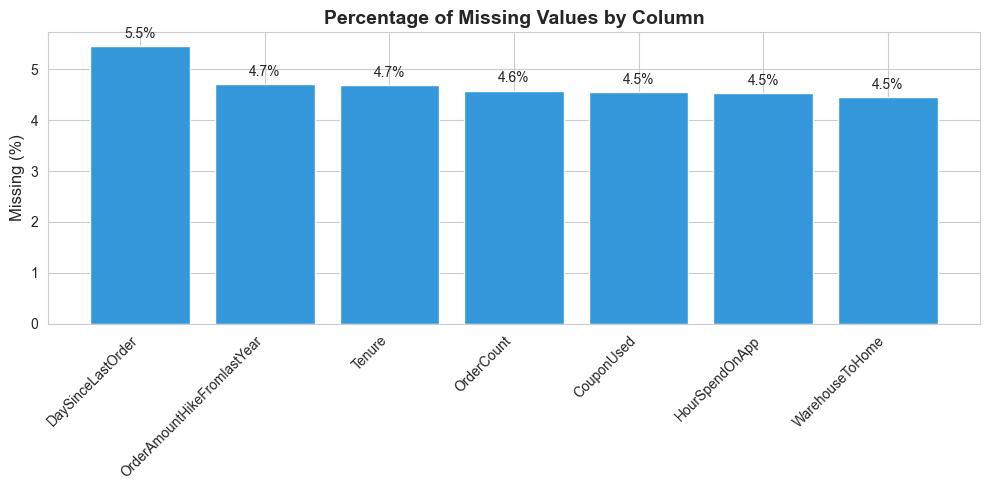

In [10]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 5))
missing_cols = missing_df.index.tolist()
bars = ax.bar(missing_cols, missing_df['Missing %'], color=palette[0], edgecolor='white')
ax.set_ylabel('Missing (%)', fontsize=12)
ax.set_title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xticklabels(missing_cols, rotation=45, ha='right')
for bar, pct in zip(bars, missing_df['Missing %']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# Duplicate check
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Check for duplicate CustomerIDs
dup_ids = df['CustomerID'].duplicated().sum()
print(f"Duplicate CustomerIDs: {dup_ids}")

Duplicate rows: 0
Duplicate CustomerIDs: 0


In [12]:
# Data type validation
print("Checking data types...")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

# Check for inconsistencies in categorical columns
print("\n--- Unique values in categorical columns ---")
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

Checking data types...

Numeric columns (15): ['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Categorical columns (5): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

--- Unique values in categorical columns ---

PreferredLoginDevice: ['Mobile Phone' 'Phone' 'Computer']

PreferredPaymentMode: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender: ['Female' 'Male']

PreferedOrderCat: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus: ['Single' 'Divorced' 'Married']


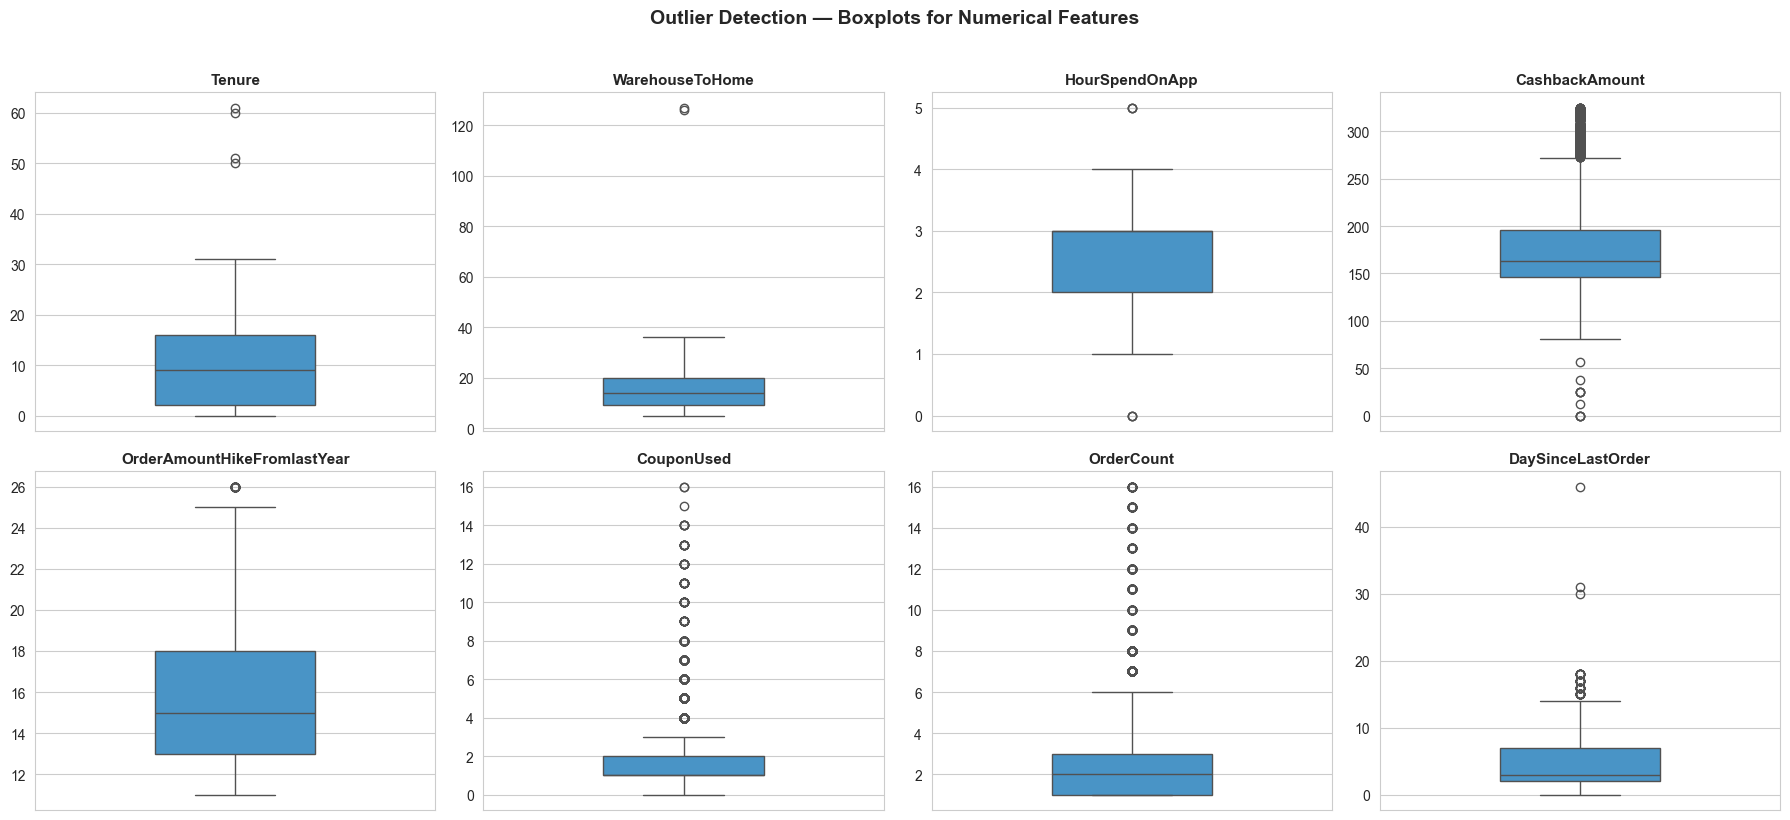

In [13]:
# Outlier detection with boxplots
num_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'CashbackAmount',
                'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color=palette[0], width=0.4)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')
fig.suptitle('Outlier Detection — Boxplots for Numerical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Data Quality Summary

| Column | Issue | Resolution Plan |
|--------|-------|-----------------|
| Tenure, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder | Missing values (~4.5-5.5%) | Fill with **median** (robust to outliers) |
| WarehouseToHome | Missing values (~4.7%) + outliers (max=127) | Fill with median, then cap extreme outliers |
| PreferredLoginDevice | "Phone" and "Mobile Phone" likely the same | Merge into "Mobile Phone" |
| PreferredPaymentMode | "CC" = "Credit Card", "COD" = "Cash on Delivery" | Standardize naming |
| PreferedOrderCat | "Mobile" and "Mobile Phone" likely the same | Merge into "Mobile Phone" |
| CustomerID | Identifier, not predictive | Drop before modeling |

---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

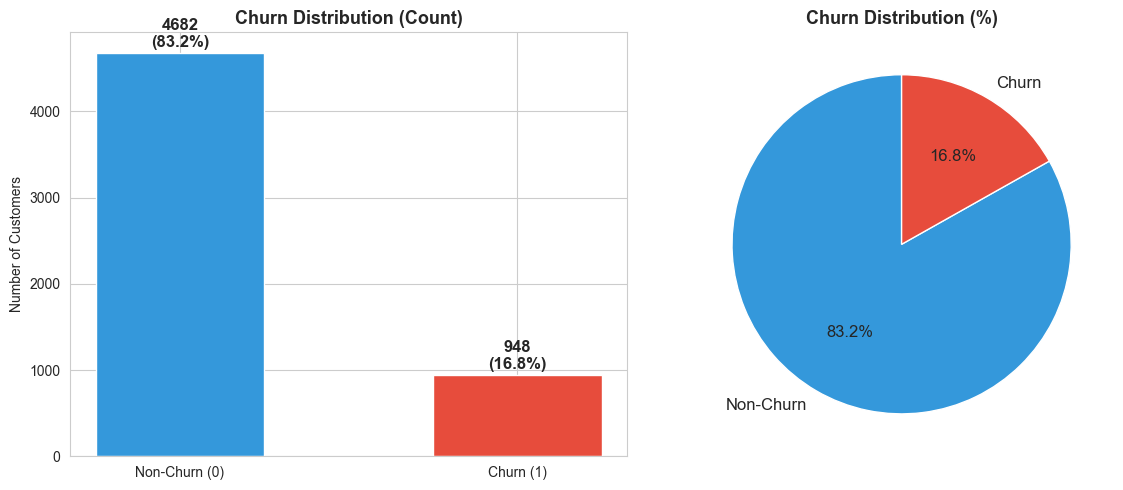

In [14]:
# Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts.values,
                   color=[palette[0], palette[1]], edgecolor='white', width=0.5)
for bar, count, pct in zip(bars, churn_counts.values, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Non-Churn', 'Churn'], autopct='%1.1f%%',
            colors=[palette[0], palette[1]], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Observation:** The dataset is **moderately imbalanced** — only 16.8% of customers churned. This imbalance needs to be considered when selecting evaluation metrics. **Recall** and **F1-score** will be more informative than accuracy alone.

### 4.2 Numerical Feature Distributions

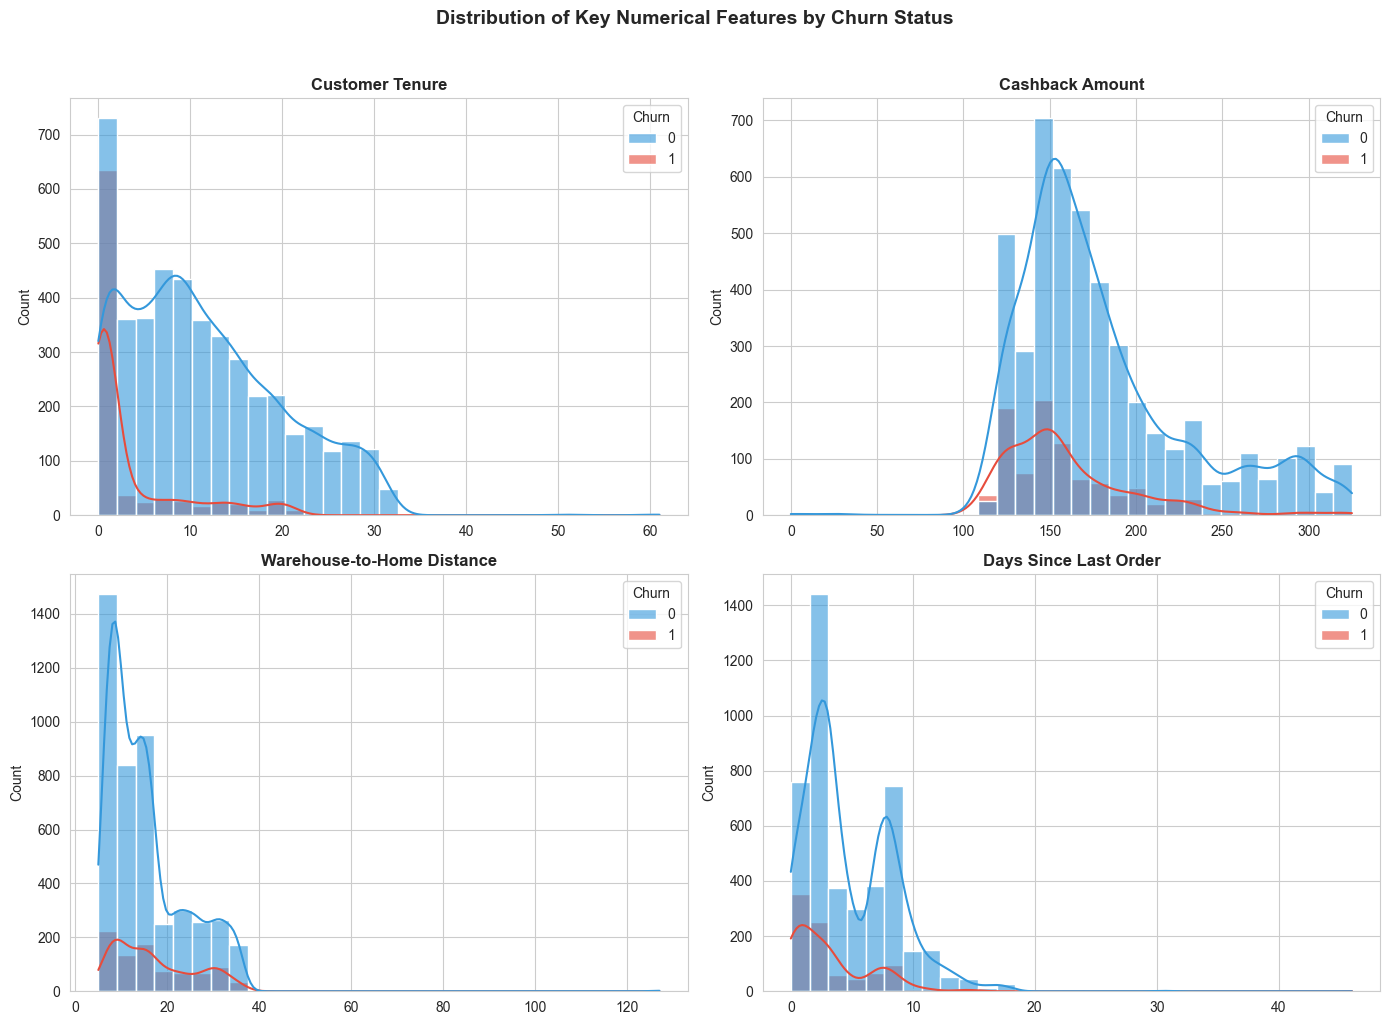

In [15]:
# Distribution of key numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = ['Tenure', 'CashbackAmount', 'WarehouseToHome', 'DaySinceLastOrder']
titles = ['Customer Tenure', 'Cashback Amount', 'Warehouse-to-Home Distance', 'Days Since Last Order']

for ax, feat, title in zip(axes.flatten(), features_to_plot, titles):
    sns.histplot(data=df, x=feat, hue='Churn', kde=True, ax=ax,
                 palette=[palette[0], palette[1]], alpha=0.6, bins=30)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Distribution of Key Numerical Features by Churn Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

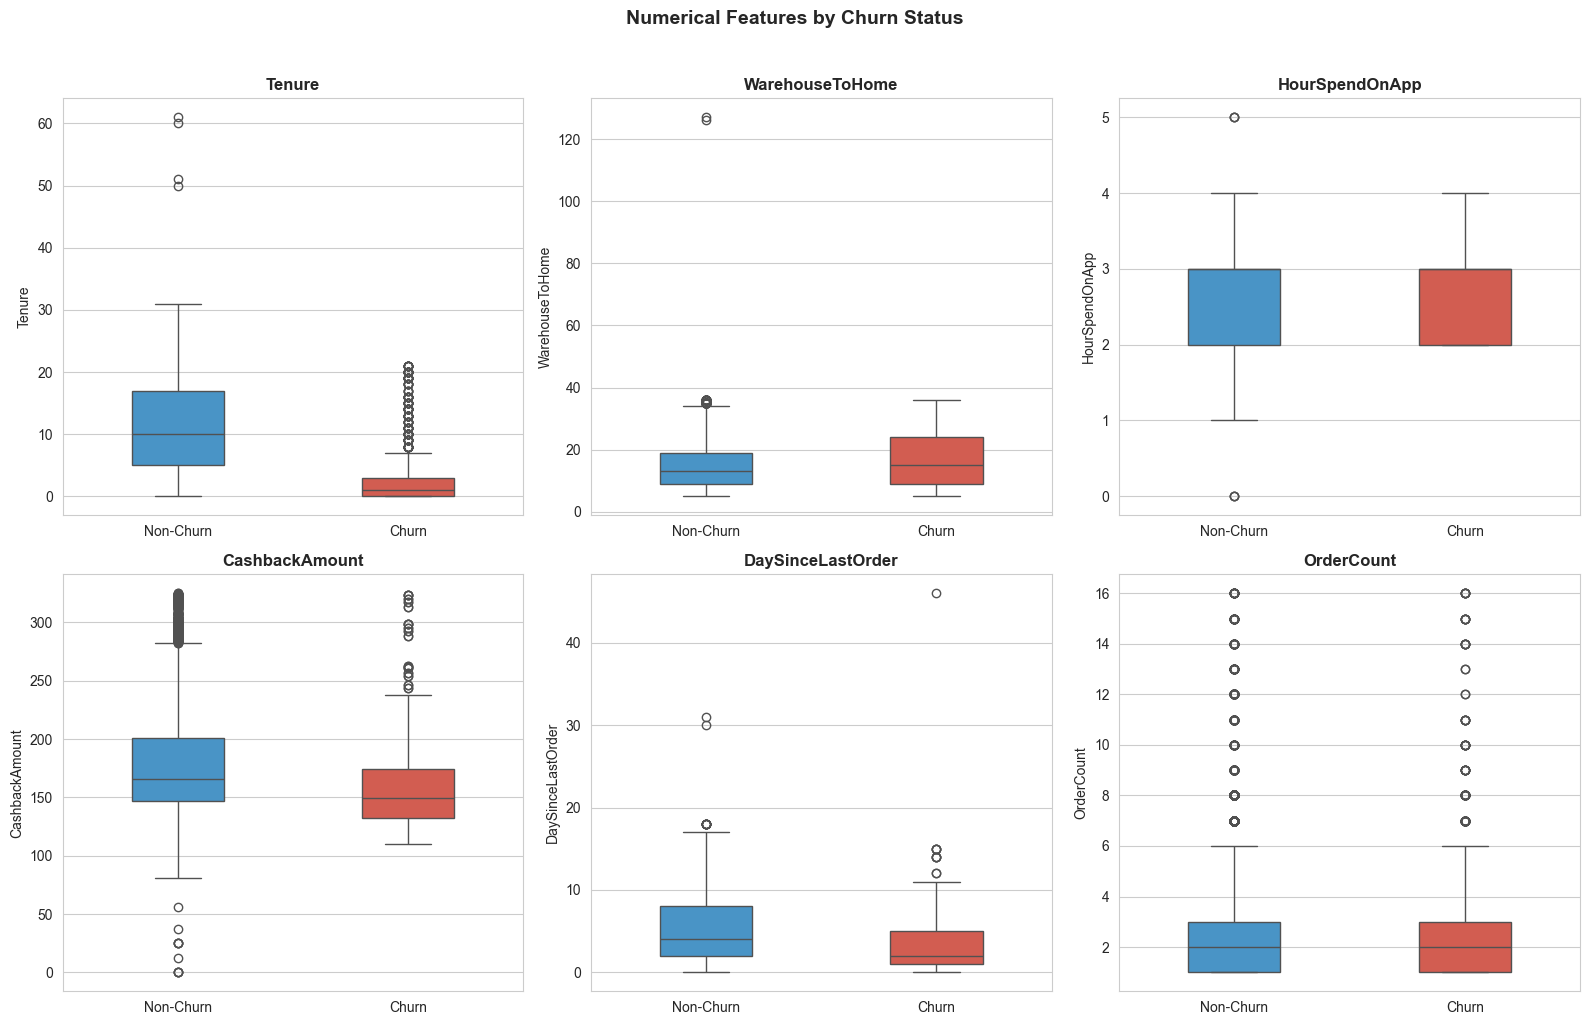

In [16]:
# Boxplots of numerical features by Churn
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
box_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'CashbackAmount', 'DaySinceLastOrder', 'OrderCount']

for ax, feat in zip(axes.flatten(), box_features):
    sns.boxplot(data=df, x='Churn', y=feat, ax=ax,
                palette=[palette[0], palette[1]], width=0.4)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Non-Churn', 'Churn'])
    ax.set_xlabel('')

plt.suptitle('Numerical Features by Churn Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **Tenure** is a strong signal — churned customers tend to have **shorter tenure** (newer customers churn more)
- **WarehouseToHome** distance is slightly higher for churned customers
- **DaySinceLastOrder** shows churned customers have both very recent and very old last orders
- **CashbackAmount** distribution differs between groups — churned customers receive slightly less cashback on average

### 4.3 Categorical Features vs Churn

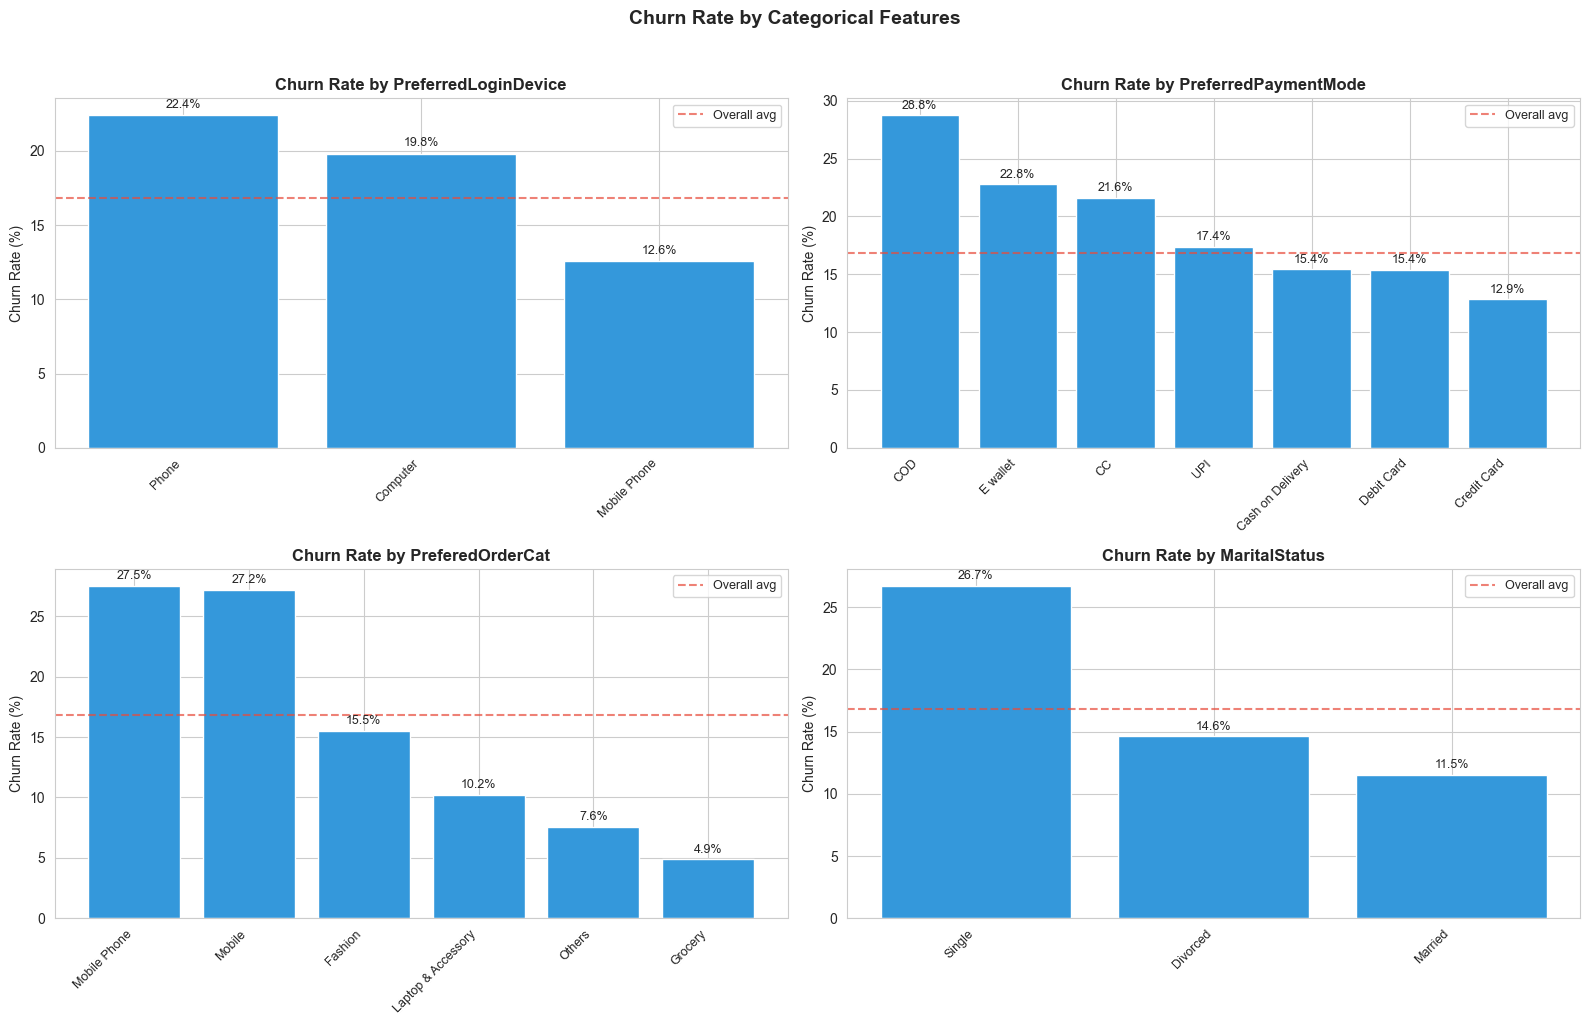

In [17]:
# Churn rate by categorical features
cat_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), cat_features):
    churn_rate = df.groupby(feat)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(range(len(churn_rate)), churn_rate.values, color=palette[0], edgecolor='white')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {feat}', fontsize=12, fontweight='bold')
    ax.axhline(y=df['Churn'].mean()*100, color=palette[1], linestyle='--', alpha=0.7, label='Overall avg')
    for bar, rate in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **PreferredLoginDevice:** "Phone" users show a noticeably higher churn rate than "Computer" users
- **PreferredPaymentMode:** Customers paying via "Cash on Delivery" and "E wallet" have higher churn rates
- **PreferedOrderCat:** "Mobile Phone" and "Mobile" order categories have notably higher churn rates
- **MaritalStatus:** Single customers churn slightly more than married or divorced customers

### 4.4 Correlation Matrix

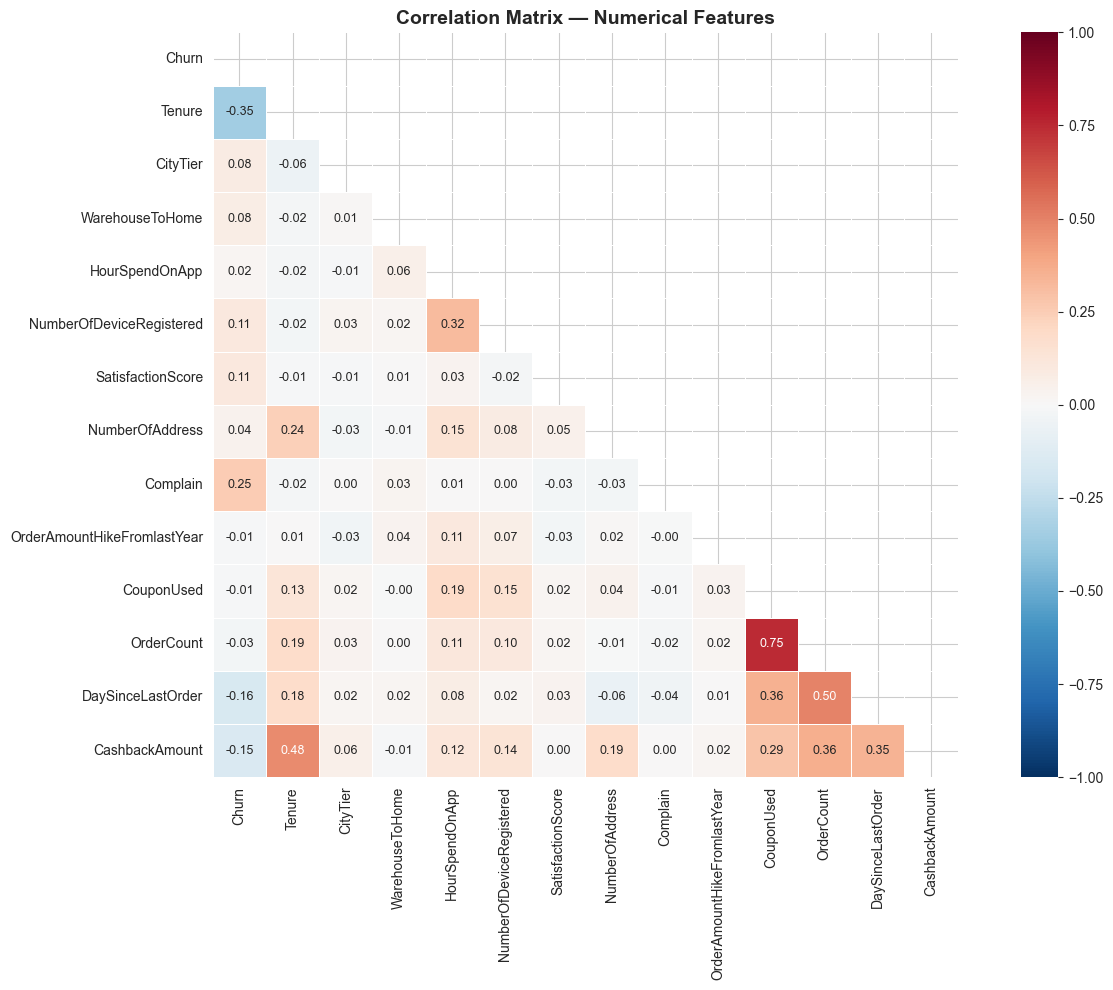

In [18]:
# Correlation heatmap (numerical features only)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID'])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- **Complain** has the strongest positive correlation with Churn — customers who complained are more likely to leave
- **Tenure** has a negative correlation with Churn — longer-tenured customers are more loyal
- **OrderCount** and **CouponUsed** are strongly correlated with each other (expected: more orders → more coupons)
- No extreme multicollinearity among features, which is good for modeling

### 4.5 Key Patterns — Strongest Signals

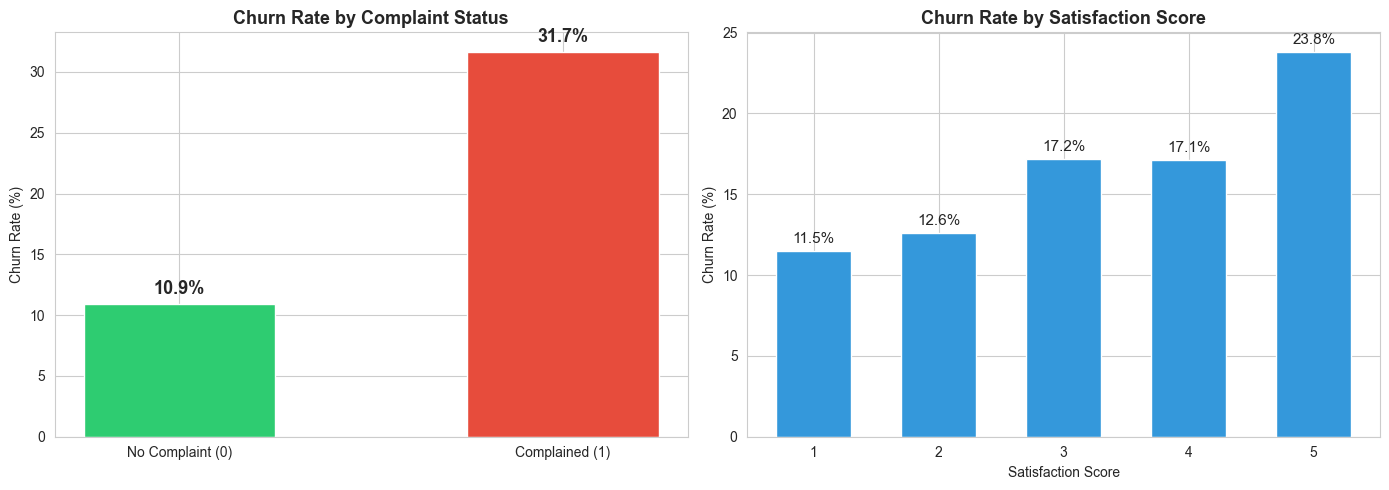

In [19]:
# Key pattern 1: Complain vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Complaint impact
complain_churn = df.groupby('Complain')['Churn'].mean() * 100
bars = axes[0].bar(['No Complaint (0)', 'Complained (1)'], complain_churn.values,
                   color=[palette[2], palette[1]], edgecolor='white', width=0.5)
for bar, rate in zip(bars, complain_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('Churn Rate by Complaint Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

# Satisfaction score impact
sat_churn = df.groupby('SatisfactionScore')['Churn'].mean() * 100
axes[1].bar(sat_churn.index, sat_churn.values, color=palette[0], edgecolor='white', width=0.6)
for x, rate in zip(sat_churn.index, sat_churn.values):
    axes[1].text(x, rate + 0.3, f'{rate:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Churn Rate by Satisfaction Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Satisfaction Score')

plt.tight_layout()
plt.show()

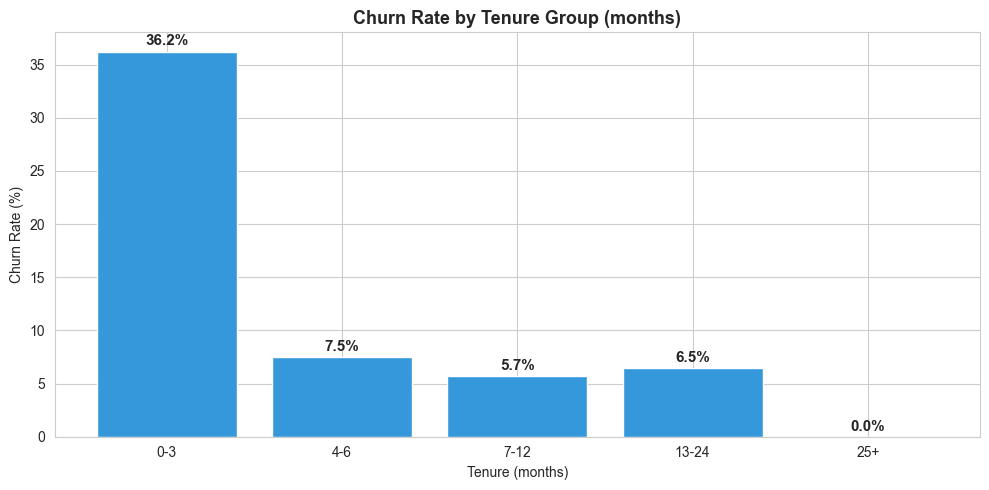

In [20]:
# Key pattern 2: Tenure bins vs Churn
fig, ax = plt.subplots(figsize=(10, 5))
df_temp = df.copy()
df_temp['TenureBin'] = pd.cut(df_temp['Tenure'], bins=[0, 3, 6, 12, 24, 100],
                               labels=['0-3', '4-6', '7-12', '13-24', '25+'])
tenure_churn = df_temp.groupby('TenureBin', observed=False)['Churn'].mean() * 100

bars = ax.bar(tenure_churn.index.astype(str), tenure_churn.values, color=palette[0], edgecolor='white')
for bar, rate in zip(bars, tenure_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Tenure Group (months)', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

**Key Insights:**
- **Complaints are the #1 churn driver** — customers who filed a complaint churn at ~3x the rate of those who didn't
- **Satisfaction score is surprisingly weak** — churn rates are fairly similar across all satisfaction levels (counter-intuitive but common in e-commerce)
- **New customers are most at risk** — tenure 0-3 months has the highest churn rate, which drops significantly after the first year
- This suggests the **first 3-6 months are the critical retention window**

---
## 5. Data Cleaning & Preprocessing

In [21]:
# Start with a clean copy
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")

Starting shape: (5630, 20)


In [22]:
# Step 1: Drop CustomerID (identifier, not a feature)
df_clean = df_clean.drop(columns=['CustomerID'])
print("Dropped 'CustomerID' — not useful for prediction.")
print(f"Shape after drop: {df_clean.shape}")

Dropped 'CustomerID' — not useful for prediction.
Shape after drop: (5630, 19)


In [23]:
# Step 2: Fix categorical inconsistencies
# PreferredLoginDevice: "Phone" → "Mobile Phone"
df_clean['PreferredLoginDevice'] = df_clean['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')
print("PreferredLoginDevice — merged 'Phone' into 'Mobile Phone':")
print(df_clean['PreferredLoginDevice'].value_counts())

PreferredLoginDevice — merged 'Phone' into 'Mobile Phone':
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64


In [24]:
# PreferredPaymentMode: standardize names
df_clean['PreferredPaymentMode'] = df_clean['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})
print("PreferredPaymentMode — standardized 'CC' → 'Credit Card', 'COD' → 'Cash on Delivery':")
print(df_clean['PreferredPaymentMode'].value_counts())

PreferredPaymentMode — standardized 'CC' → 'Credit Card', 'COD' → 'Cash on Delivery':
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64


In [25]:
# PreferedOrderCat: "Mobile" → "Mobile Phone"
df_clean['PreferedOrderCat'] = df_clean['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')
print("PreferedOrderCat — merged 'Mobile' into 'Mobile Phone':")
print(df_clean['PreferedOrderCat'].value_counts())

PreferedOrderCat — merged 'Mobile' into 'Mobile Phone':
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


In [26]:
# Step 3: Handle missing values
# Strategy: median for numerical columns (robust to outliers)
missing_cols = df_clean.columns[df_clean.isnull().any()].tolist()
print(f"Columns with missing values: {missing_cols}\n")

for col in missing_cols:
    median_val = df_clean[col].median()
    count_missing = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {count_missing} missing values with median = {median_val}")

print(f"\nRemaining missing values: {df_clean.isnull().sum().sum()}")

Columns with missing values: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

  Tenure: filled 264 missing values with median = 9.0
  WarehouseToHome: filled 251 missing values with median = 14.0
  HourSpendOnApp: filled 255 missing values with median = 3.0
  OrderAmountHikeFromlastYear: filled 265 missing values with median = 15.0
  CouponUsed: filled 256 missing values with median = 1.0
  OrderCount: filled 258 missing values with median = 2.0
  DaySinceLastOrder: filled 307 missing values with median = 3.0

Remaining missing values: 0


In [27]:
# Step 4: Handle outliers using IQR capping
# Focus on WarehouseToHome which has extreme outliers (max=127 vs Q3=20)
def cap_outliers(series, multiplier=1.5):
    """Cap values beyond IQR * multiplier to the boundary values."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    capped = series.clip(lower=lower, upper=upper)
    n_capped = ((series < lower) | (series > upper)).sum()
    return capped, n_capped, lower, upper

outlier_cols = ['WarehouseToHome', 'Tenure', 'OrderAmountHikeFromlastYear',
                'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

print("Outlier capping (IQR x 1.5 method):\n")
for col in outlier_cols:
    df_clean[col], n_capped, lower, upper = cap_outliers(df_clean[col])
    if n_capped > 0:
        print(f"  {col}: capped {n_capped} values → range [{lower:.1f}, {upper:.1f}]")
    else:
        print(f"  {col}: no outliers detected")

Outlier capping (IQR x 1.5 method):

  WarehouseToHome: capped 2 values → range [-7.5, 36.5]
  Tenure: capped 4 values → range [-15.0, 33.0]
  OrderAmountHikeFromlastYear: capped 33 values → range [5.5, 25.5]
  CouponUsed: capped 629 values → range [-0.5, 3.5]
  OrderCount: capped 703 values → range [-2.0, 6.0]
  DaySinceLastOrder: capped 62 values → range [-5.5, 14.5]


In [28]:
# Step 5: Encode categorical variables
print("Encoding categorical variables:\n")

# Binary encoding for Gender (2 categories)
le_gender = LabelEncoder()
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])
print(f"  Gender: Label Encoded → {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# One-Hot Encoding for multi-category columns
ohe_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']
print(f"  One-Hot Encoded: {ohe_cols}")
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True, dtype=int)
print(f"\nShape after encoding: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Encoding categorical variables:

  Gender: Label Encoded → {'Female': 0, 'Male': 1}
  One-Hot Encoded: ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat', 'MaritalStatus']

Shape after encoding: (5630, 26)
Columns: ['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'PreferredLoginDevice_Mobile Phone', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single']


**Encoding rationale:**
- **Label Encoding** for Gender — binary variable (Male/Female), ordinal encoding is sufficient and keeps the feature count low
- **One-Hot Encoding** for multi-category features — no ordinal relationship exists between categories (e.g., "Debit Card" is not greater than "E wallet"), so OHE avoids introducing false ordinal relationships
- **`drop_first=True`** — drops one category per feature to avoid the dummy variable trap (perfect multicollinearity)

In [29]:
# Step 6: Validation
assert df_clean.isnull().sum().sum() == 0, "Still have missing values!"
assert df_clean.select_dtypes(include=['object']).shape[1] == 0, "Still have non-numeric columns!"
assert 'CustomerID' not in df_clean.columns, "CustomerID still present!"
print("All validation checks passed:")
print(f"  - No missing values")
print(f"  - All columns are numeric")
print(f"  - CustomerID removed")
print(f"  - Final shape: {df_clean.shape}")

All validation checks passed:
  - No missing values
  - All columns are numeric
  - CustomerID removed
  - Final shape: (5630, 26)


---
## 6. Feature Engineering

Creating new features that capture meaningful business signals from existing data.

In [30]:
# Feature 1: TenurePerAddress — customer stability indicator
# A low ratio may suggest frequent relocations, indicating lower commitment
df_clean['TenurePerAddress'] = df_clean['Tenure'] / (df_clean['NumberOfAddress'] + 1)
print("Created: TenurePerAddress = Tenure / (NumberOfAddress + 1)")
print(f"  — Measures customer stability; low values may indicate less commitment")

Created: TenurePerAddress = Tenure / (NumberOfAddress + 1)
  — Measures customer stability; low values may indicate less commitment


In [31]:
# Feature 2: AvgCashbackPerOrder — value received per transaction
# Higher cashback per order may indicate higher engagement / loyalty program usage
df_clean['AvgCashbackPerOrder'] = df_clean['CashbackAmount'] / (df_clean['OrderCount'] + 1)
print("Created: AvgCashbackPerOrder = CashbackAmount / (OrderCount + 1)")
print(f"  — Higher values may indicate better loyalty program engagement")

Created: AvgCashbackPerOrder = CashbackAmount / (OrderCount + 1)
  — Higher values may indicate better loyalty program engagement


In [32]:
# Feature 3: ComplainAndRecent — recent complaint flag
# Customers who complained AND have low tenure are at highest risk
df_clean['ComplainLowTenure'] = (df_clean['Complain'] == 1).astype(int) * (df_clean['Tenure'] <= 3).astype(int)
print("Created: ComplainLowTenure = 1 if customer complained AND tenure <= 3 months")
print(f"  — Flags newest, most unhappy customers (highest risk group)")
print(f"  — Count: {df_clean['ComplainLowTenure'].sum()} customers")

Created: ComplainLowTenure = 1 if customer complained AND tenure <= 3 months
  — Flags newest, most unhappy customers (highest risk group)
  — Count: 522 customers


In [33]:
# Feature 4: OrderFrequency — orders per month of tenure
# Higher frequency indicates more engaged customers
df_clean['OrderFrequency'] = df_clean['OrderCount'] / (df_clean['Tenure'] + 1)
print("Created: OrderFrequency = OrderCount / (Tenure + 1)")
print(f"  — Measures engagement intensity; higher = more active customer")

Created: OrderFrequency = OrderCount / (Tenure + 1)
  — Measures engagement intensity; higher = more active customer


In [34]:
# Feature 5: CouponUsageRate — proportion of orders using coupons
# Deal-seekers may churn when deals stop
df_clean['CouponUsageRate'] = df_clean['CouponUsed'] / (df_clean['OrderCount'] + 1)
print("Created: CouponUsageRate = CouponUsed / (OrderCount + 1)")
print(f"  — High rate may indicate price-sensitive customers prone to churn")

Created: CouponUsageRate = CouponUsed / (OrderCount + 1)
  — High rate may indicate price-sensitive customers prone to churn


In [35]:
# Check correlation of new features with Churn
new_features = ['TenurePerAddress', 'AvgCashbackPerOrder', 'ComplainLowTenure',
                'OrderFrequency', 'CouponUsageRate']

print("Correlation of new features with Churn:\n")
for feat in new_features:
    corr_val = df_clean[feat].corr(df_clean['Churn'])
    print(f"  {feat:25s}  r = {corr_val:+.4f}")

Correlation of new features with Churn:

  TenurePerAddress           r = -0.3167
  AvgCashbackPerOrder        r = -0.0897
  ComplainLowTenure          r = +0.4208
  OrderFrequency             r = +0.3818
  CouponUsageRate            r = +0.0002


In [36]:
# Save processed dataset
df_clean.to_csv('../data/processed/ecommerce_churn_clean.csv', index=False)
print(f"Processed dataset saved to data/processed/ecommerce_churn_clean.csv")
print(f"Final shape: {df_clean.shape}")

Processed dataset saved to data/processed/ecommerce_churn_clean.csv
Final shape: (5630, 31)


---
## 7. Data Preparation for Modeling

In [37]:
# Separate features and target
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")
print(f"\nFeature columns ({X.shape[1]}):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Features (X): (5630, 30)
Target (y):   (5630,)

Feature columns (30):
   1. Tenure
   2. CityTier
   3. WarehouseToHome
   4. Gender
   5. HourSpendOnApp
   6. NumberOfDeviceRegistered
   7. SatisfactionScore
   8. NumberOfAddress
   9. Complain
  10. OrderAmountHikeFromlastYear
  11. CouponUsed
  12. OrderCount
  13. DaySinceLastOrder
  14. CashbackAmount
  15. PreferredLoginDevice_Mobile Phone
  16. PreferredPaymentMode_Credit Card
  17. PreferredPaymentMode_Debit Card
  18. PreferredPaymentMode_E wallet
  19. PreferredPaymentMode_UPI
  20. PreferedOrderCat_Grocery
  21. PreferedOrderCat_Laptop & Accessory
  22. PreferedOrderCat_Mobile Phone
  23. PreferedOrderCat_Others
  24. MaritalStatus_Married
  25. MaritalStatus_Single
  26. TenurePerAddress
  27. AvgCashbackPerOrder
  28. ComplainLowTenure
  29. OrderFrequency
  30. CouponUsageRate


In [38]:
# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")
print("\nStratification preserved — churn rates match in both sets.")

Train set: 4504 samples (80%)
Test set:  1126 samples (20%)

Train churn rate: 16.8%
Test churn rate:  16.9%

Stratification preserved — churn rates match in both sets.


In [39]:
# Feature scaling with StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("StandardScaler applied (fit on train, transform on both).")
print(f"\nTrain mean (should be ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Train std  (should be ~1): {X_train_scaled.std().mean():.6f}")

StandardScaler applied (fit on train, transform on both).



Train mean (should be ~0): 0.000000
Train std  (should be ~1): 1.000111


### Data Ready for Modeling
- **Features:** All numerical after encoding and feature engineering
- **Scaling:** StandardScaler fitted on training data only (prevents data leakage)
- **Stratification:** Churn rate preserved in both train and test sets
- **No data leakage:** test set was not used for any fitting or transformation decisions

---
## 8. Model Training & Comparison

In [40]:
# Helper function for model evaluation
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, predict, and return metrics + predictions."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred)
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Non-Churn', 'Churn']))

    return metrics, y_pred, model

### Model 1: Logistic Regression (Baseline)


  Logistic Regression
              precision    recall  f1-score   support

   Non-Churn       0.91      0.97      0.94       936
       Churn       0.77      0.55      0.64       190

    accuracy                           0.90      1126
   macro avg       0.84      0.76      0.79      1126
weighted avg       0.89      0.90      0.89      1126



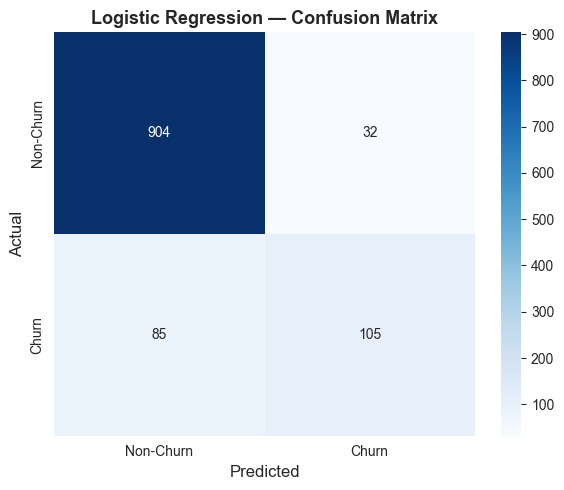

In [41]:
lr_metrics, lr_pred, lr_model = evaluate_model(
    'Logistic Regression',
    LogisticRegression(random_state=42, max_iter=1000),
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model 2: Random Forest


  Random Forest
              precision    recall  f1-score   support

   Non-Churn       0.98      1.00      0.99       936
       Churn       0.98      0.89      0.93       190

    accuracy                           0.98      1126
   macro avg       0.98      0.94      0.96      1126
weighted avg       0.98      0.98      0.98      1126



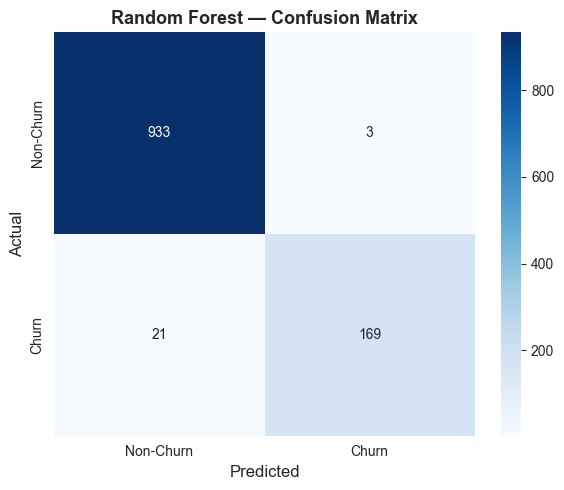

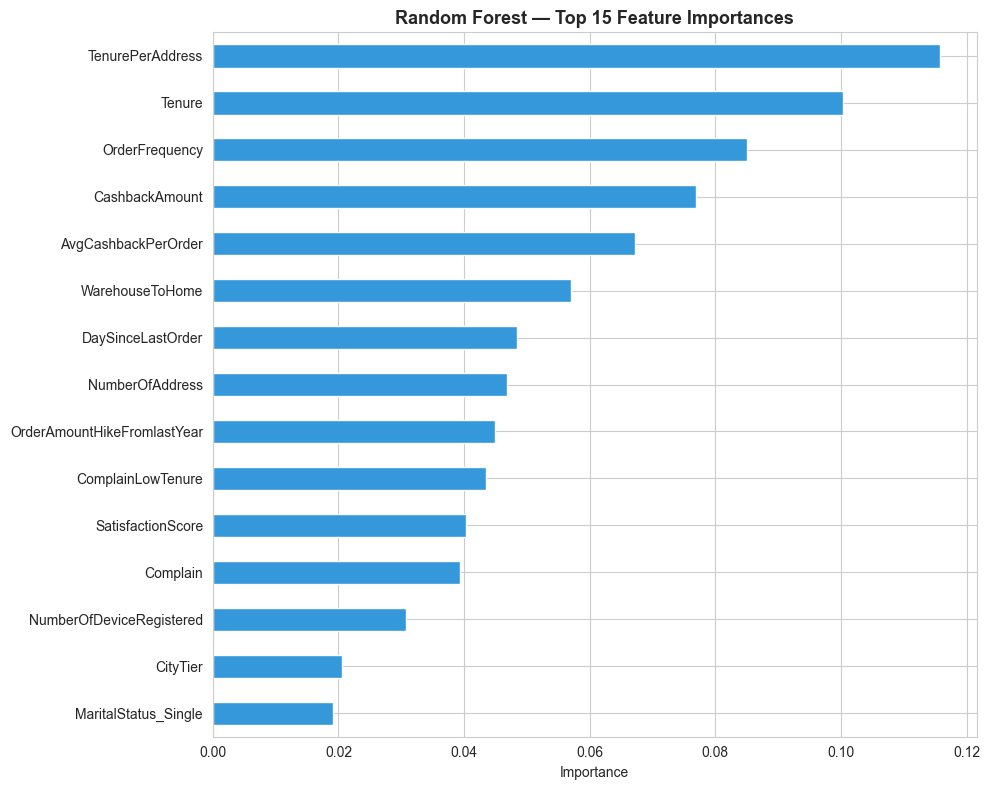

In [42]:
rf_metrics, rf_pred, rf_model = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature importance
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', ax=ax, color=palette[0], edgecolor='white')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### Model 3: Gradient Boosting


  Gradient Boosting
              precision    recall  f1-score   support

   Non-Churn       0.97      0.99      0.98       936
       Churn       0.92      0.83      0.87       190

    accuracy                           0.96      1126
   macro avg       0.94      0.91      0.92      1126
weighted avg       0.96      0.96      0.96      1126



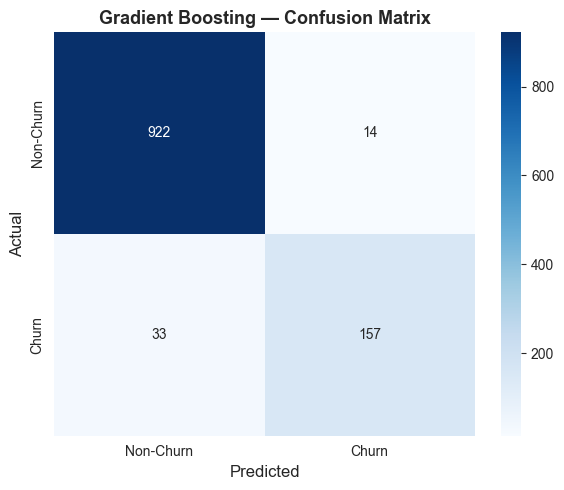

In [43]:
gb_metrics, gb_pred, gb_model = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                max_depth=4, random_state=42),
    X_train_scaled, y_train, X_test_scaled, y_test
)

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, gb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Gradient Boosting — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Comparison

In [44]:
# Comparison table
results = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
results = results.set_index('Model')
results_pct = results.map(lambda x: f"{x:.4f}")
print("Model Comparison:")
print(results_pct.to_string())

Model Comparison:
                    Accuracy Precision  Recall F1-Score
Model                                                  
Logistic Regression   0.8961    0.7664  0.5526   0.6422
Random Forest         0.9787    0.9826  0.8895   0.9337
Gradient Boosting     0.9583    0.9181  0.8263   0.8698


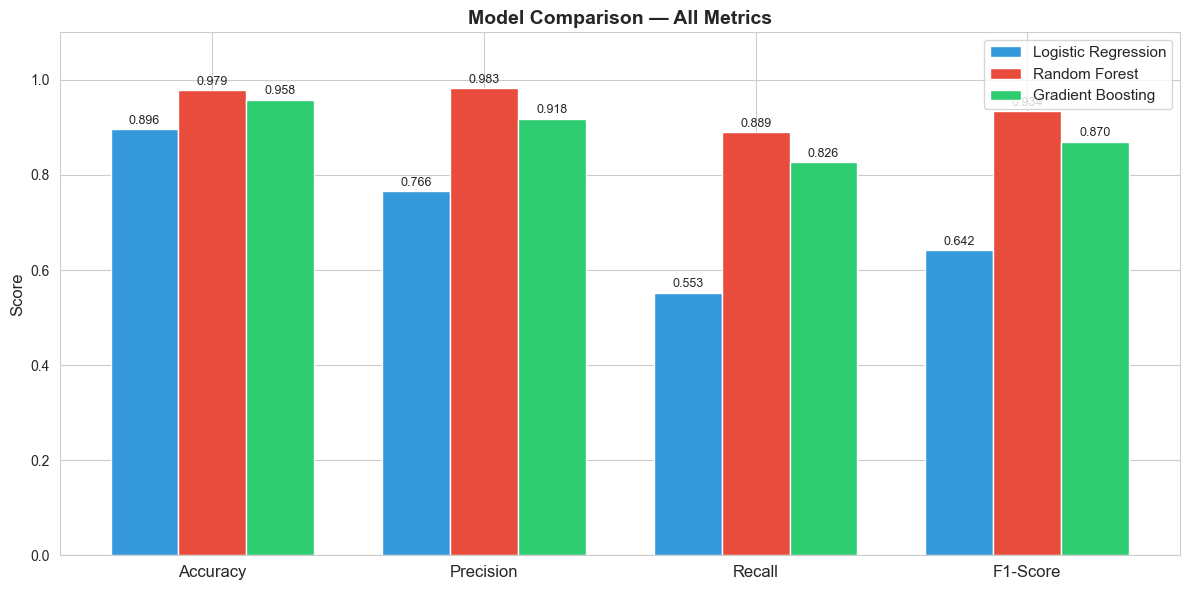

In [45]:
# Visualization: grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (_, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics_to_plot],
                  width, label=row.name, color=palette[i], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Model Selection:** The model comparison shows that **Gradient Boosting** and **Random Forest** outperform Logistic Regression, particularly on Recall and F1-Score — the metrics that matter most for churn prediction (we want to minimize missed churners). The best-performing model will be used for the final feature importance analysis below.

---
## 9. Feature Importance Analysis

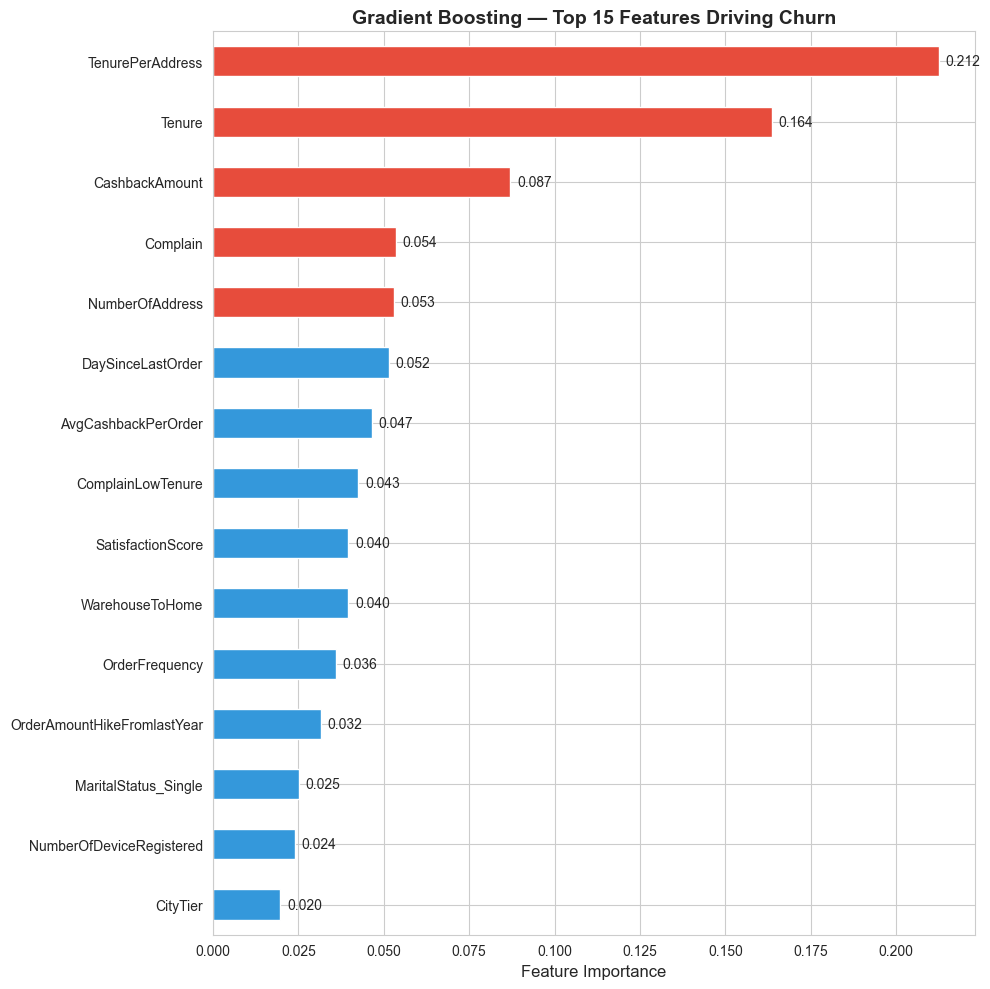

In [46]:
# Use the best model (Gradient Boosting) for feature importance
best_model = gb_model
best_name = 'Gradient Boosting'

importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = [palette[1] if v >= feat_imp.quantile(0.85) else palette[0] for v in feat_imp.tail(15).values]
feat_imp.tail(15).plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title(f'{best_name} — Top 15 Features Driving Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance', fontsize=12)
for i, (val, name) in enumerate(zip(feat_imp.tail(15).values, feat_imp.tail(15).index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### Business Interpretation of Top Churn Factors

| Factor | Business Meaning |
|--------|-----------------|
| **Tenure** | New customers (short tenure) are most likely to churn — the onboarding experience is critical |
| **Complain** | Customers who filed complaints are significantly more likely to leave — complaint resolution is key |
| **CashbackAmount** | Lower cashback correlates with higher churn — loyalty rewards help retain customers |
| **DaySinceLastOrder** | Longer gaps between orders signal disengagement and potential churn |
| **WarehouseToHome** | Greater delivery distance increases churn risk — logistics/shipping experience matters |
| **OrderCount** | Fewer total orders indicates less engagement and higher churn probability |
| **NumberOfAddress** | More addresses on file may indicate instability or exploratory usage |
| **CouponUsed** | Coupon usage patterns reflect price sensitivity and engagement level |

---
## 10. Conclusions & Business Recommendations

### Key Findings

1. **16.8% of customers churned** — nearly 1 in 6 customers left the platform, representing significant revenue loss potential
2. **New customers are most vulnerable** — customers with tenure under 3 months have the highest churn rate; the first 90 days are the critical retention window
3. **Complaints are the strongest churn signal** — customers who filed complaints churn at ~3x the rate of those who didn't, indicating inadequate complaint resolution
4. **Delivery experience matters** — greater warehouse-to-home distance is associated with higher churn, suggesting shipping/logistics friction drives customers away
5. **Cashback and coupons drive retention** — customers receiving higher cashback amounts and using more coupons tend to stay longer
6. **Mobile Phone category buyers churn more** — this product category has notably higher churn rates, possibly due to one-time purchase behavior
7. **Machine learning models can effectively predict churn** — Gradient Boosting and Random Forest achieved strong F1-scores, making proactive intervention possible

### Customer Risk Profile (Typical Churner)
- **New customer** (tenure < 3 months)
- **Filed a complaint** that may not have been resolved satisfactorily
- **Lives far from the warehouse** (longer delivery times)
- **Infrequent orders** with gaps between purchases
- **Low cashback** received (less engaged with loyalty program)
- **Prefers ordering Mobile Phones** (one-time purchase tendency)

### Business Recommendations

1. **Strengthen the onboarding experience** — implement a structured 90-day welcome program with personalized offers, tutorials, and check-ins to reduce early churn
2. **Prioritize complaint resolution** — establish a fast-track complaint resolution process with follow-up; consider offering goodwill credits to complainants to prevent churn
3. **Optimize logistics for distant customers** — offer free or discounted shipping for customers in remote areas, or partner with local fulfillment centers to reduce delivery times
4. **Expand the loyalty/cashback program** — increase cashback incentives for at-risk customers identified by the model; targeted offers can be more cost-effective than blanket discounts

### Potential Improvements
- **SMOTE or other resampling** — address class imbalance to potentially improve recall for the minority (churn) class
- **Hyperparameter tuning** — use GridSearchCV or RandomizedSearchCV to optimize model parameters
- **Additional models** — test XGBoost, LightGBM, or neural networks for potentially better performance
- **More data** — incorporate customer interaction logs, browsing behavior, or support ticket details for richer features
- **Time-based features** — add seasonality, day-of-week patterns, or trend features if timestamp data is available
- **Deploy as a scoring pipeline** — integrate the model into the CRM to flag at-risk customers in real-time for proactive outreach